In [177]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


(5000, 9)
lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object


<Axes: ylabel='Count'>

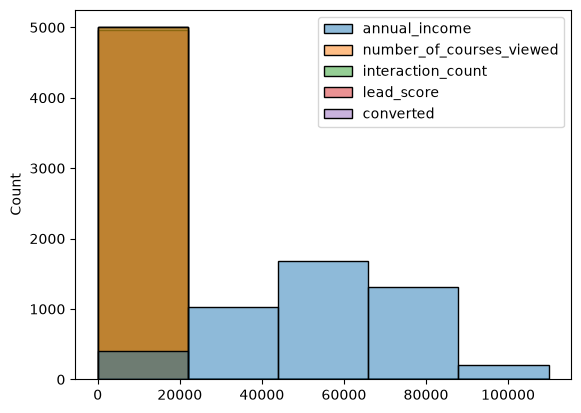

In [178]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print(np.shape(df))
print(df.dtypes)
sns.histplot(df, bins=5)

In [179]:
##Data Prep

In [180]:
df.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [181]:
df[['lead_source', 'industry', 'employment_status', 'location']] = df[['lead_source', 'industry', 'employment_status', 'location']].fillna('NA')
df[['annual_income', 'lead_score']] = df[['annual_income', 'lead_score']].fillna(0)
df.isna().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [182]:
df.industry.nunique()

7

In [183]:
df['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

In [184]:
corr_df = df[['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']]
corr_matrix = corr_df.corr()
print (corr_matrix)

                          annual_income  number_of_courses_viewed  \
annual_income                  1.000000                  0.161300   
number_of_courses_viewed       0.161300                  1.000000   
interaction_count              0.122842                  0.721609   
lead_score                     0.229496                  0.757204   

                          interaction_count  lead_score  
annual_income                      0.122842    0.229496  
number_of_courses_viewed           0.721609    0.757204  
interaction_count                  1.000000    0.915746  
lead_score                         0.915746    1.000000  


In [185]:
##Split the data

In [186]:
from sklearn.model_selection import train_test_split
df = df.copy ()
y = df['converted'].values
del df['converted']

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)
df_full_train.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
4227,events,healthcare,employed,south_america,47301.0,5,7,0.69
4676,organic_search,technology,unemployed,asia,0.0,1,5,0.57
800,events,finance,unemployed,asia,47970.0,0,0,0.17
3671,organic_search,retail,self_employed,south_america,52847.0,3,3,0.45
4193,paid_ads,finance,employed,africa,73460.0,1,4,0.42


In [187]:
df_train.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
4702,paid_ads,finance,employed,asia,65980.0,2,3,0.37
2155,events,finance,employed,south_america,71662.0,0,0,0.09
289,referral,NA,employed,asia,40220.0,2,5,0.55
1822,organic_search,finance,employed,north_america,88352.0,2,2,0.45
3442,events,technology,employed,north_america,89316.0,1,5,0.00


In [188]:
from sklearn.metrics import mutual_info_score

y_train = y[df_train.index]
df_train['converted'] = y_train
df_train.head()

categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns
def q3_mutual_info_score(series):
    return mutual_info_score(series, y_train)
mutual_info = df_train[categorical_cols].apply(q3_mutual_info_score)
print(mutual_info.sort_values(ascending=False).round(2))

del df_train['converted']
df_train.head()

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64


/tmp/ipykernel_2187/1973699487.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns


,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
4702,paid_ads,finance,employed,asia,65980.0,2,3,0.37
2155,events,finance,employed,south_america,71662.0,0,0,0.09
289,referral,NA,employed,asia,40220.0,2,5,0.55
1822,organic_search,finance,employed,north_america,88352.0,2,2,0.45
3442,events,technology,employed,north_america,89316.0,1,5,0.00


In [189]:
##Question 4

In [190]:
df_train[categorical_cols].nunique()

lead_source          6
industry             7
employment_status    5
location             6
dtype: int64

In [191]:
from sklearn.feature_extraction import DictVectorizer

df_train[['lead_source', 'location']].iloc[:8]

,lead_source,location
4702,paid_ads,asia
2155,events,south_america
289,referral,asia
1822,organic_search,north_america
3442,events,north_america
521,paid_ads,europe
3804,organic_search,europe
678,organic_search,south_america


In [192]:
numerical_cols = list(df_train.select_dtypes(exclude=['object', 'category']).columns)
numerical_categorical = numerical_cols + list(categorical_cols)

dicts_train = df_train[numerical_categorical].to_dict(orient='records')
dicts_train[0]

{'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'interaction_count': 3,
 'lead_score': 0.37,
 'lead_source': 'paid_ads',
 'industry': 'finance',
 'employment_status': 'employed',
 'location': 'asia'}

In [193]:
dv = DictVectorizer(sparse=False)
dv.fit(dicts_train)
x_train = dv.transform(dicts_train)

In [194]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=retail',
       'industry=technology', 'interaction_count', 'lead_score',
       'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=europe',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [195]:
print(len(dv.get_feature_names_out()))

28


In [196]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [197]:
print(x_train.shape)
print(y_train.shape)

(3000, 28)
(3000,)


In [198]:
###prep val data

In [199]:
df_val.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
682,NA,technology,employed,asia,80457.0,3,5,0.64
4312,events,NA,self_employed,africa,74480.0,0,1,0.26
647,paid_ads,technology,student,africa,43944.0,2,4,0.49
878,organic_search,finance,employed,europe,73795.0,2,6,0.68
777,paid_ads,finance,NA,north_america,76619.0,1,3,0.40


In [200]:
y_val = y[df_val.index]
df_val.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
682,NA,technology,employed,asia,80457.0,3,5,0.64
4312,events,NA,self_employed,africa,74480.0,0,1,0.26
647,paid_ads,technology,student,africa,43944.0,2,4,0.49
878,organic_search,finance,employed,europe,73795.0,2,6,0.68
777,paid_ads,finance,NA,north_america,76619.0,1,3,0.40


In [203]:
y_val.shape

(1000,)

In [204]:
numerical_cols_val = list(df_val.select_dtypes(exclude=['object', 'category']).columns)
categorical_cols_val = list(df_val.select_dtypes(include=['object', 'category']).columns)

numerical_categorical_val = numerical_cols_val + categorical_cols_val

dicts_val = df_val[numerical_categorical_val].to_dict(orient='records')
dicts_val[0]


/tmp/ipykernel_2187/2882744778.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_val = list(df_val.select_dtypes(include=['object', 'category']).columns)


{'annual_income': 80457.0,
 'number_of_courses_viewed': 3,
 'interaction_count': 5,
 'lead_score': 0.64,
 'lead_source': 'NA',
 'industry': 'technology',
 'employment_status': 'employed',
 'location': 'asia'}

In [205]:
dv = DictVectorizer(sparse=False)
dv.fit(dicts_val)
x_val = dv.transform(dicts_val)

In [206]:
model.predict(x_val)

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,

In [207]:
x_val.shape

(1000, 28)

In [208]:
model.predict_proba(x_val)[:,1].round(3)

array([0.617, 0.444, 0.604, 0.646, 0.522, 0.779, 0.607, 0.545, 0.768,
       0.528, 0.75 , 0.647, 0.569, 0.51 , 0.599, 0.466, 0.628, 0.692,
       0.691, 0.591, 0.5  , 0.556, 0.653, 0.608, 0.723, 0.516, 0.561,
       0.572, 0.67 , 0.556, 0.636, 0.703, 0.455, 0.619, 0.653, 0.428,
       0.639, 0.623, 0.66 , 0.517, 0.538, 0.761, 0.483, 0.742, 0.637,
       0.412, 0.454, 0.642, 0.439, 0.871, 0.725, 0.756, 0.53 , 0.667,
       0.504, 0.576, 0.723, 0.725, 0.651, 0.629, 0.722, 0.592, 0.708,
       0.615, 0.497, 0.744, 0.528, 0.614, 0.56 , 0.59 , 0.694, 0.73 ,
       0.761, 0.607, 0.525, 0.567, 0.58 , 0.449, 0.558, 0.636, 0.645,
       0.778, 0.695, 0.724, 0.62 , 0.562, 0.675, 0.685, 0.498, 0.743,
       0.622, 0.623, 0.603, 0.599, 0.674, 0.629, 0.684, 0.686, 0.708,
       0.658, 0.629, 0.615, 0.602, 0.555, 0.636, 0.677, 0.727, 0.555,
       0.618, 0.527, 0.746, 0.513, 0.715, 0.639, 0.754, 0.595, 0.462,
       0.685, 0.609, 0.692, 0.722, 0.58 , 0.616, 0.54 , 0.643, 0.543,
       0.48 , 0.431,

In [209]:
y_pred = model.predict_proba(x_val)[:,1].round(3)
converted_pred = (y_pred >= 0.5)
y_val == converted_pred.astype(int)

array([ True, False, False,  True, False,  True,  True, False,  True,
        True,  True,  True,  True, False,  True,  True,  True, False,
        True, False, False, False,  True,  True,  True,  True, False,
        True,  True, False,  True,  True, False,  True, False,  True,
        True,  True,  True,  True, False,  True,  True, False, False,
        True, False,  True,  True,  True,  True,  True, False,  True,
       False, False, False,  True,  True,  True, False,  True,  True,
       False,  True,  True, False,  True, False,  True,  True, False,
        True,  True, False,  True,  True,  True, False,  True,  True,
        True, False,  True,  True, False, False,  True, False,  True,
        True,  True,  True,  True, False, False, False,  True,  True,
        True, False,  True, False, False,  True,  True,  True,  True,
        True, False,  True, False, False,  True,  True,  True, False,
       False,  True,  True,  True, False,  True,  True,  True, False,
        True,  True,

In [218]:
print("Q4 the accuracy rate is: ", (y_val == converted_pred).mean())

Q4 the accuracy rate is:  0.645


In [211]:
##Question 5

In [215]:
import numpy as np
# 1. Train the original baseline model with ALL features (No rounding)
dicts_train_base = df_train[numerical_categorical].to_dict(orient='records')
X_train_base = dv.fit_transform(dicts_train_base)

model_base = LogisticRegression(solver='liblinear', random_state=42)
model_base.fit(X_train_base, y_train)

# Calculate baseline validation accuracy
dicts_val_base = df_val[numerical_categorical].to_dict(orient='records')
X_val_base = dv.transform(dicts_val_base)
y_pred_base = model_base.predict_proba(X_val_base)[:, 1]
baseline_accuracy = (y_val == (y_pred_base >= 0.5)).mean()

print(f"Original Baseline Accuracy: {baseline_accuracy:.4f}\n")

# 2. Loop through each feature, eliminate it, and record the difference
elimination_results = {}

for feature in numerical_categorical:
    # Create a temporary list of features excluding the current one
    subset_features = [f for f in numerical_categorical if f != feature]
    
    # Process training data without this feature
    dicts_train_sub = df_train[subset_features].to_dict(orient='records')
    X_train_sub = dv.fit_transform(dicts_train_sub)
    
    # Retrain the model on the subset
    model_sub = LogisticRegression(solver='liblinear', random_state=42)
    model_sub.fit(X_train_sub, y_train)
    
    # Process validation data without this feature
    dicts_val_sub = df_val[subset_features].to_dict(orient='records')
    X_val_sub = dv.transform(dicts_val_sub)
    
    # Calculate new validation accuracy
    y_pred_sub = model_sub.predict_proba(X_val_sub)[:, 1]
    sub_accuracy = (y_val == (y_pred_sub >= 0.5)).mean()
    
    # Calculate the exact difference (Original - Without Feature)
    difference = baseline_accuracy - sub_accuracy
    elimination_results[feature] = difference

# 3. Print the sorted results (smallest difference = least useful feature)
for feat, diff in sorted(elimination_results.items(), key=lambda x: x[1]):
    print(f"Feature: {feat:<25} | Accuracy Difference: {diff:.4f}")


Original Baseline Accuracy: 0.6450

Feature: annual_income             | Accuracy Difference: -0.0790
Feature: industry                  | Accuracy Difference: 0.0000
Feature: employment_status         | Accuracy Difference: 0.0000
Feature: location                  | Accuracy Difference: 0.0000
Feature: lead_score                | Accuracy Difference: 0.0010
Feature: number_of_courses_viewed  | Accuracy Difference: 0.0020
Feature: lead_source               | Accuracy Difference: 0.0030
Feature: interaction_count         | Accuracy Difference: 0.0440


In [217]:
np.set_printoptions(suppress=True)

# 1. Prepare your baseline full feature data matrices
dicts_train = df_train[numerical_categorical].to_dict(orient='records')
X_train = dv.fit_transform(dicts_train)

dicts_val = df_val[numerical_categorical].to_dict(orient='records')
X_val = dv.transform(dicts_val)

# 2. Define the list of C values to test
c_values = [0.000001, 0.00001, 0.0001, 0.001]

print("C Value    | Validation Accuracy (Rounded to 3 digits)")
print("-" * 50)

# 3. Loop through each C value, train, and evaluate
for c in c_values:
    # Initialize the model with the current C value
    model = LogisticRegression(solver='liblinear', C=c, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict on validation data
    y_pred = model.predict_proba(X_val)[:, 1]
    converted_pred = (y_pred >= 0.5).astype(int)
    
    # Calculate accuracy and round strictly to 3 decimal places
    accuracy = (y_val == converted_pred).mean()
    rounded_accuracy = round(accuracy, 3)
    
    print(f"{c:<10} | {rounded_accuracy:.3f}")


C Value    | Validation Accuracy (Rounded to 3 digits)
--------------------------------------------------
1e-06      | 0.598
1e-05      | 0.598
0.0001     | 0.613
0.001      | 0.645
